# Recap on L1 and L2 regularization, Dropout and Data Augmentation

## Pre-requisites
To start this lession with Regularisation **all students must be aware** of the following concepts:
* Forward and Backward Propogation in ANN
* Overfitting and Bias Variance Tradeoff
* Optimization



## Learning Objectives
By the end of this lesson, **all learners** will be able to:

<!-- [ C=Condition + A=Actor + B=Behaviour + D=Degree ]  -->

<!-- [Remember] -->
* Recall the problem of overfitting and underfitting with diagrammatic representations
<!-- [Understand] -->
* Summarize the need of regularisation in models to increase testing accuracy
<!-- [Apply] -->
* Implement the concept of L1 and L2 regularisation to generate mathematical formulation for weight updates
<!-- [Analyze] -->
* Analyze and Differentiate L1 and L2 regularization along with contours for RSS

* Explain dropout and understand how it helps in regularization
<!-- [Remember] -->
* Explain what data augmentation is and how does it help in regularization



## Introduction to Regularisation
In deep learning, we often need a model that not only performs well in training data, but also performs appreciably in new inputs. Many strategies can be used to **reduce error on test data at the expense of increasing error on training data**, the strategies collectively known as regularisation.

Before diving into the concept of regularisation, let's revise what overfitting is.

<center>
<figure>


<p>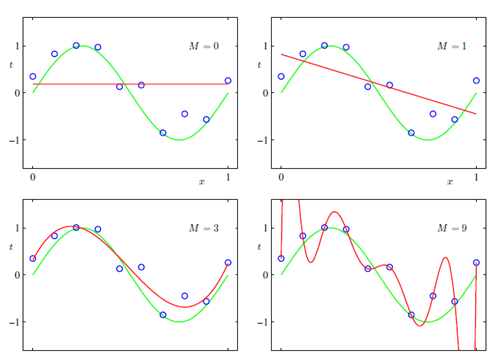</p>
<figcaption align="center">Figure 1: Fitting a model to data(Christopher M. Bishop, Pattern Recognition and Machine Learning) </figcaption>
</figure>
</center>

The diagram above has been adapted from the book **"Pattern Recognition and Machine Learning by Christopher M. Bishop"**. The figure shows plots of polynomial having various **orders of M=0,1,3,9** shown by red curves that has been fitted to the training data. The green curve is the **expected polynomial function which fits the training data.**

Talking about the origin of regularisation, it's quiet idiotic and quiet interesting. We can see on the bottom right corner of the figure that the fitted line is rather zigzag (irregular). So, **to make the curve more regular(well fitted)** the concept of regularisation is put forward. Long things short, **regularisation was introduced to make irregular curve more regular.**

It can be seen that the first curve fits poorly on training data and will perform poorly on test data as well. Whereas, **the last curve of order M=9 fits the training data perfectly but this model will perform poorly on test data**. The first two cases with M=0 and M=1 are referred to as **underfitting** and the last case with M=9 is referred to as **overfitting.** When overfitted, a model tries to capture noise in training data as well. Such models are not acceptable to use in real-world. There are various techniques to avoid overfitting, and these **techniques are collectively known as regularisation**. Regularisation reduces error on test dataset by fitting the dataset in such a way that overfitting can be avoided. To do so, in the above example, we can use **addition of penalty term in error function so that the coefficients are discouraged to take extreme values.**







## L1 and L2 Regularisation
### Mathematical Formulation and Example
We know that the mean squared loss or **Residual Sum of Squares (RSS)** for a model is defined as:

$$
L = L_e = \sum_ {}{}{(\hat{y}-y)^2}
$$

Now, we add another term to the loss function.

$$
L = L_e + \frac{\lambda}{2} L_w
$$

where,

$$
L_w = \sum_ {w}{}{w^2}
$$
**is the sum of squares of all the weights in the network and $\lambda>0$ is the regularisation parameter whose value is to be chosen using validation set.**

While using gradient descent to update weights in the neural network, we subtract change in loss from weights of all the neurons. **The new change in loss is evaluated as below:**

$$
\frac{\partial L}{\partial w} = \frac{\partial L_e}{\partial w} + \frac{\lambda}{2}  \frac{\partial L_w}{\partial w}
$$

$$
\frac{\partial L}{\partial w} = \frac{\partial L_e}{\partial w} + \frac{\lambda w}{n}
$$

The term $\frac{\partial L_e}{\partial w}$ can be evaluated using gradient descent. We then update the weights using following:

$$
w = w - \alpha \frac{\partial L_e}{\partial w} - \alpha \frac{\lambda w}{n}
$$
or,
$$
w = \left( 1 - \alpha \frac{\lambda}{n} \right)w- \alpha \frac{\partial L_e}{\partial w}
$$

It is **similar to gradient descent learning rule except that we rescale weight of neurons by a factor of** $\left( 1 - \alpha \frac{\lambda}{n} \right)$.   
From above equation, we can see that in order to minimize the loss function, the coefficients $w$ should be small.

**This technique is known as L2 (ridge) regularisation.**

\


We can also use different types of regularisation term instead of the second term $L_w$ (penalty term). If we replace the second term $L_w$ by

$$
L_w = \sum_ {w}{}{\left|w\right|}
$$

This is aso called **L1 (lasso) regularisation**. When using L1 regularisation, the change in loss with respect to change in weight becomes:

$$
\frac{\partial L}{\partial w} = \frac{\partial L_e}{\partial w} + \frac{\lambda}{n} sign(w)
$$

and hence weights of neuron can be updated as:

$$
w = w - \alpha \frac{\lambda}{n}sign(w) - \alpha \frac{\partial L_e}{\partial w}
$$

\

**Now let's understand how the process of making weights smaller (weight decay) prevents overfitting.**

In the example given in first figure, if we fit the data by polynomial of degree 9, we might get equation as below:
$$
y= 0.3 + 500x -2000x^2 + 30000x^3 -90000x^4 + 200000x^5 -800000x^6 + 30000x^3 -70000x^7 + 3000x^8 -9000x^9
$$

In such model, small change in trainning data changes model largely. But if we set the parameter $\lambda$ properly and get the following equation:
$$
y= 0.3 + 5x -2x^2 + 4x^3 -0.09x^4 + 11x^5 -13x^6 + 30x^3 -40x^7 + 30x^8 -6x^9
$$
small change in input will not affect the model as much even though train set error remains similar.


Similarly, **in a neural network having neurons with small weights, the behaviour of the network won't change too much if we change few random inputs but if it has large weights, the behaviour of the network will change abruptly.**

### How regularization works?

In both L1 and L2 regularisation, if $\lambda =0$, the penalty term has no effect and if $\lambda \rightarrow \infty$, weights will approach zero. So, we need to select the right value of $\lambda$ using cross-validation or other techniques. **The coefficient estimates produced by L1 regularisation are called L1 norm and that produced by L2 regularisation is called L2 norm.**

Looking by a different perspective, ridge L2 regularisation can be thought of as solving following equation when we are building regression model with two parameters $\beta_1$ and $\beta_2$.

$$
\beta_1^2 + \beta_2^2 \leq s
$$

where, $s$ is a constant that exists for a given regularisation parameter $\lambda$.

Similarly, for L1 regularisation, we would have:

$$
\left|\beta_1\right| + \left|\beta_2\right| \leq s
$$



### Geometrical Intrepretation

The above equations can be described using the following figure:

<center>
<figure>


<p>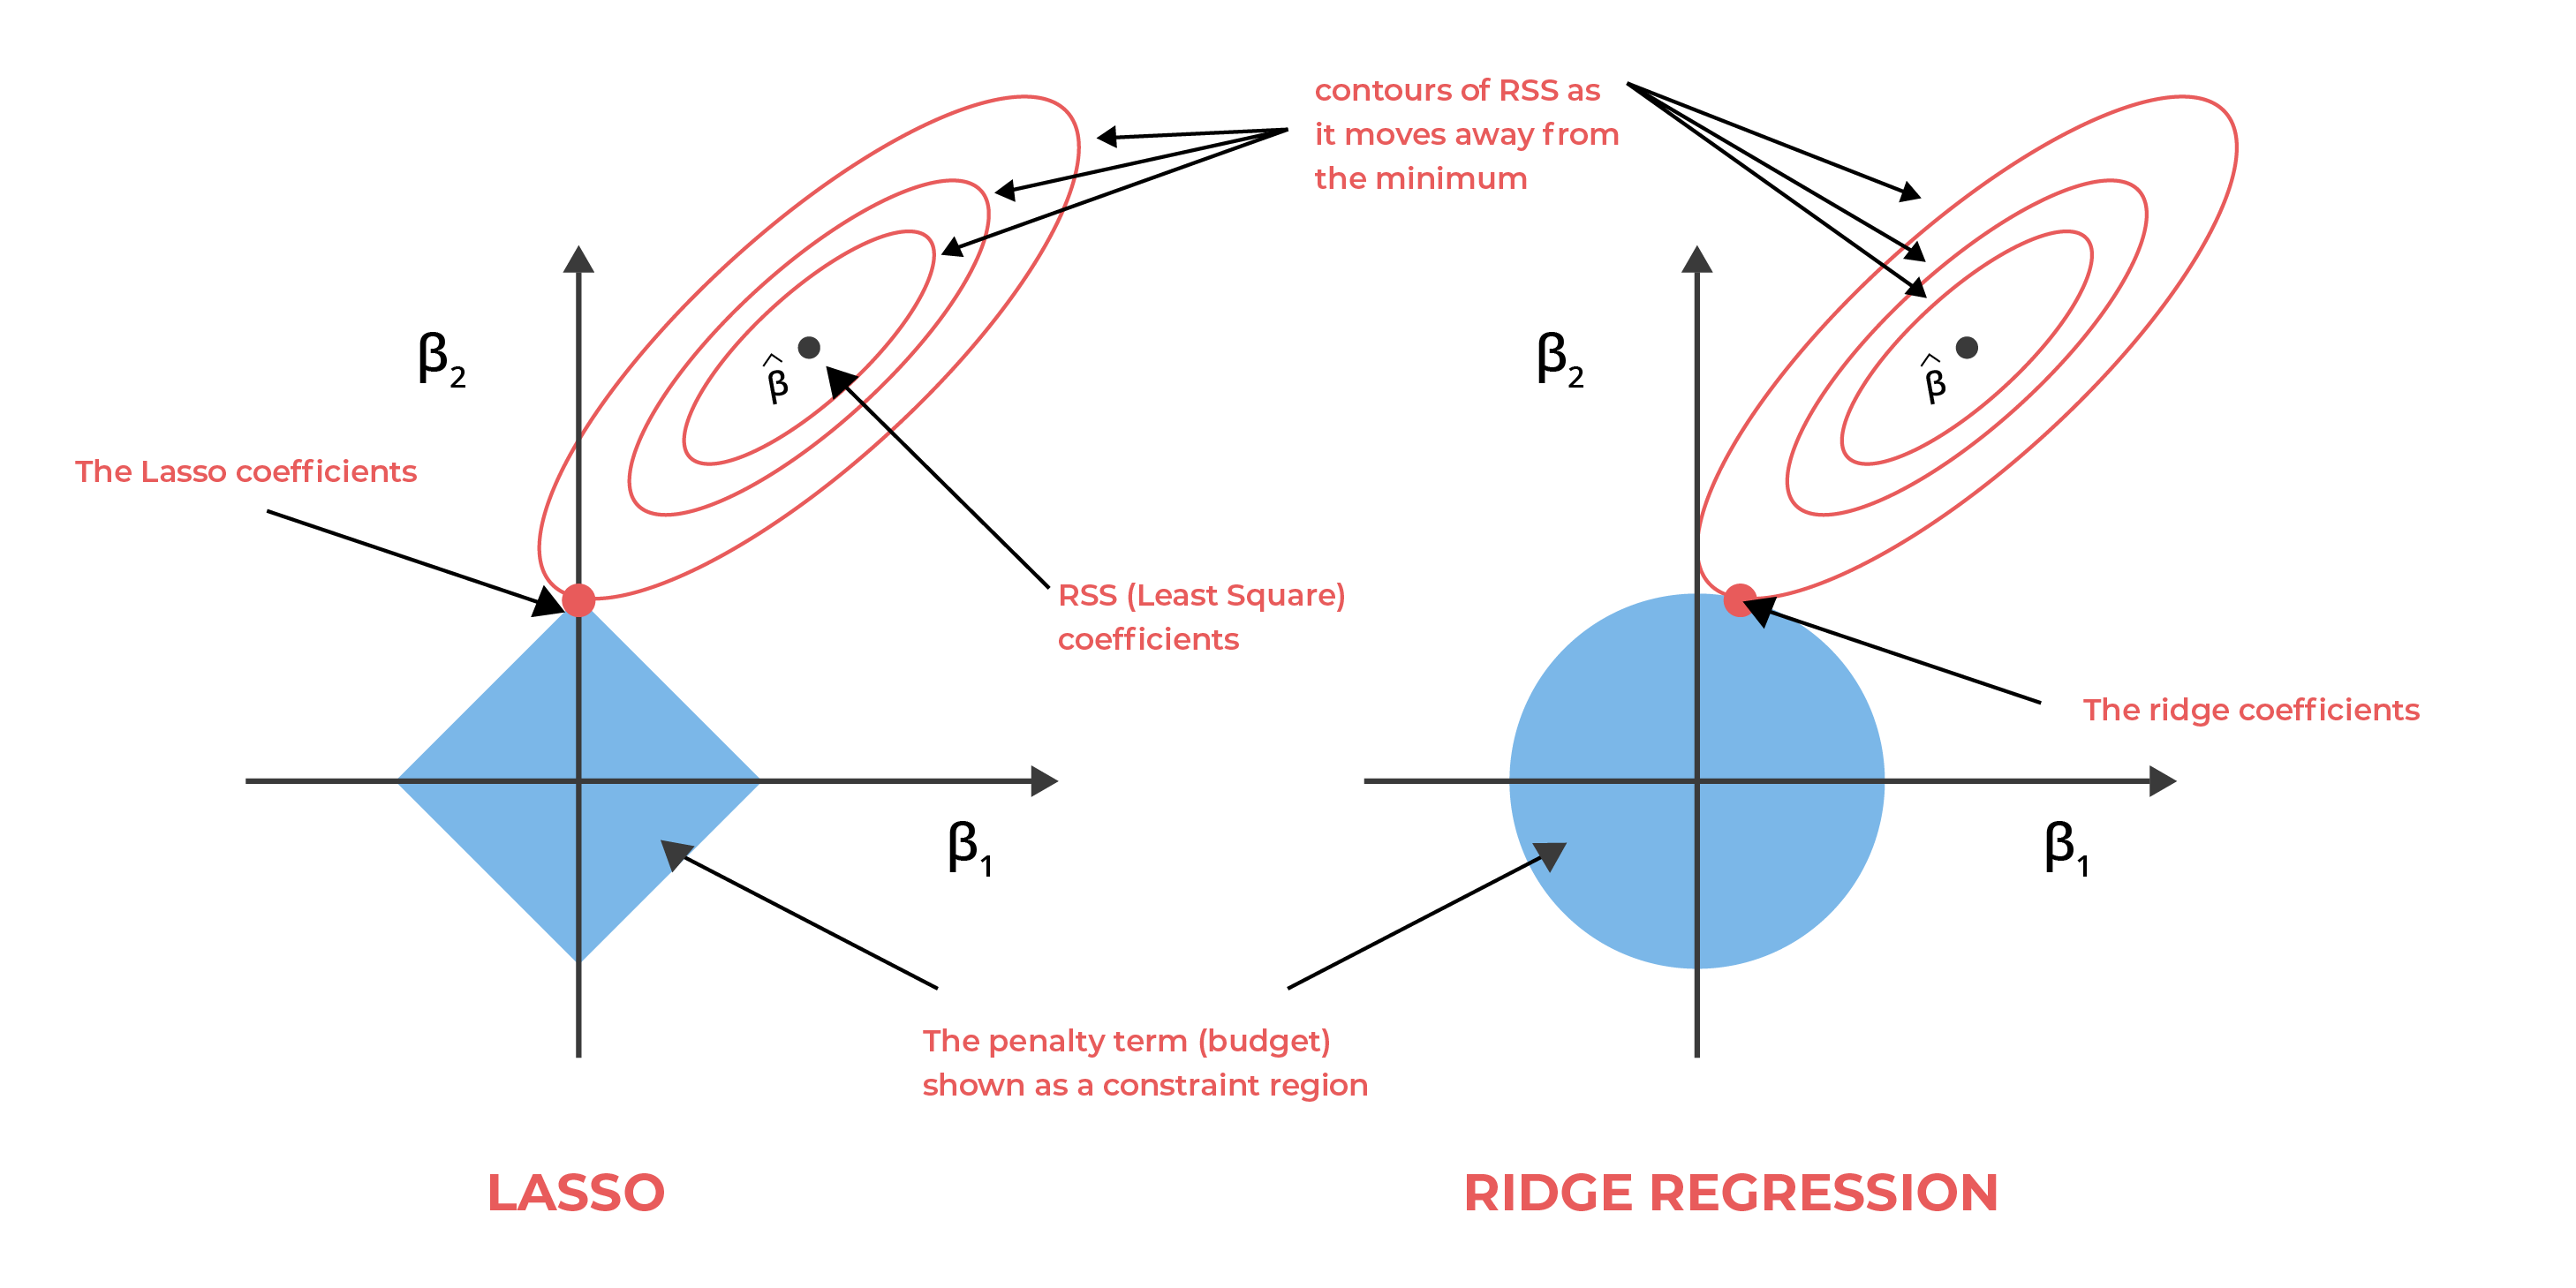</p>
<figcaption align="center">Figure 2: Geometrical Interpretation of Lasso and Ridge Regression</figcaption>
</figure>
</center>

In the above image we can see the blue bounded regions given by above equations for L1 and L2 regularisation and contours for RSS. If $\lambda$ is large, $s$ would also be small and hence the blue regions will concentrate towards origin. If $\lambda$ is small, $s$ would be large and the region will contain center of the ellipse making coefficient estimates equal to least square estimates. For a given value of $\lambda$, **the gradient descent algorithm tries to reach global minimum (center of the contours) and regularisation term pulls the coefficients towards the edges of blue region (in L1) or circumference of blue region (in L2).** They finally settle together **at points of intersection indicated by red dots**. We vary value of $\lambda$ and repeat the process until optimum value of lambda is found, whose loss function gives least error.


For the same value of $\lambda$, the area occupied by L1 norm is smaller than that of L2. **The gradient descent contour and and L1 norm occurs near axes causing coefficient of some parameters to equal zero**. This leads to feature selection. While, gradient descent contour and L2 norm occur at points further away from axes giving equal importance to all the features.





### L1 Vs L2 Regularization

Our motivation for regularisation is to **reduce underfitting by penalizing coefficents.** We studied working mechanism of both L1 and L2 Regularisation. With the knowledge comes a question when to use those? When to use L1 over L2 and vice versa? Use of either L1 or L2 regularisation depends upon our goal. Both regularisation can reduce overfitting by penalizing coefficents.

L1 addresses **multi-collinearity problem by constraining the coefficent norm and reducing some coefficent values to zero.** Since the values is reduced to zeros, L1 can also be used in feature selection. Computationally, Lasso regression (regression with an L1 penalty) is a quadratic program which requires some special tools to solve.

L2 regularisation handles multi-collinearity **by constraining the coefficent norm and keeping all the variables.** Since L2 keeps all the variables, it cannot be used in feature selection. It's unlikely to estimate a coefficient to be exactly 0. This isn't necessarily a drawback, unless a sparse coefficient vector is important for some reason.


## Introduction to Dropout
In addition to L1 and L2 regularization, dropout is another famous and computationally inexpensive regularisation technique that intends to reduce overfitting in neural network. The reason behind using dropout is that a complex neural network tends to overfit. Some neuron in $i^{th}$ layer **might be highly dependent on some of the neurons in** ${(i-1)}^{th}$ layer. In the following figure, the green neuron on third layer highly depends on red neurons of second layer.


<center>
<figure>


<p>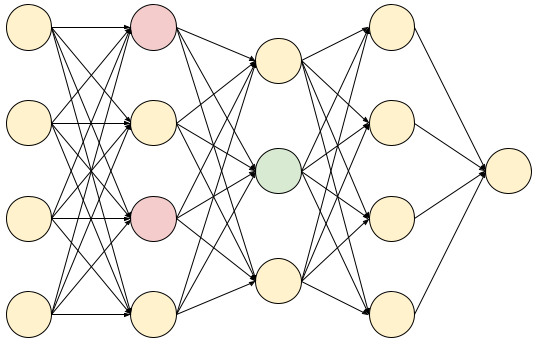</p>
<figcaption align="center">Figure 3: Dropout</figcaption>
</figure>
</center>






###  How dropout helps in regularization?
Dropout can also be thought of as **bagging of many large neural networks**. Like ensemble method performs better than a single model by capturing randomness, dropout performs better than normal neural network. But bagging such large neural network is computationally very expensive in terms of runtime and memory. So what we do is make the **models share parameters, where each model inherits subset of parameters from the parent neural network.**

A specific neuron might always learn to depend on one (or more) previous neurons (features) in order to extract information. When we remove that feature and prevent the neuron to depend on it, it will be forced to learn the information needed from the other features. Thus, at testing time, it can perform better on unseen data since it has learned how to extract information from features that are not present at testing time.   
Hence, dropout doubles the number of iterations required to converge, however training time for each epoch is less since some neurons are disabled.




<center>
<figure>


<p>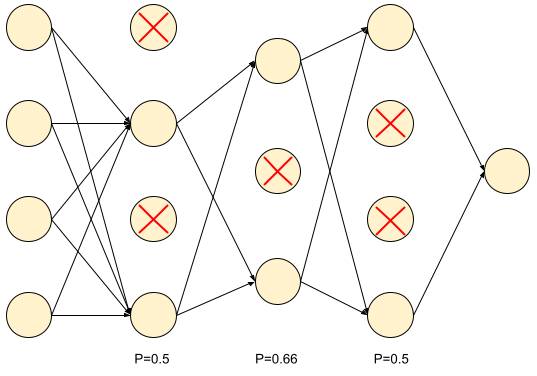</p>

</figure>
</center>


<center>
<figure>


<p>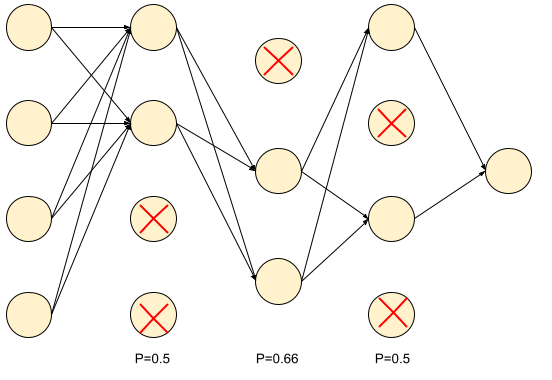</p>
<figcaption align="center">Figure 4: Dropout with $p=0.5$</figcaption>
</figure>
</center>



**How to implement dropout?**

At every iteration in **training phase**, dropout randomly removes some nodes in different layers along with the incoming and outgoing edges which is similar to inheriting weights from parent. To select which nodes to keep, we assign a mask vector $\mu$ to each layer. **The probability of keeping each node is random and a threshold(keep.probability)** is decided for each layer which determines if the node is kept or not. (Note that dropout rate = 1 - keep.probability). This defines $\mu$. Then we do backpropagation in the network.   
If we set threshold to 0.5 for a layer, there is a probability that $50\%$ nodes will be removed from that layer resulting in much smaller and simpler neural network. For above network, the resultant network by setting threshold for second and fourth layer to be 0.5 and third layer to be $66\%$ might be as follows for two different iterations.

But during **testing phase** we are not dropping any neurons, rather we scale up the neurons by a factor of keep probability. This is because at testing time all the neurons in each layers see all the neurons from the previous layers, which is a **sudden change of setting** for a neuron compared to reduced number of neurons in training time. hence, we want the outputs of the neurons at testing time to be identical to that of training time. Now, to acheive this expectation we **keep all the neurons in testing time active but scale with a factor of keep probability**. for an example, for any neuron $x$ and keep probability $p$, in testing time we adjust $x$ to $px$ to expect similar output as of training time.


<center>
<figure>


<p>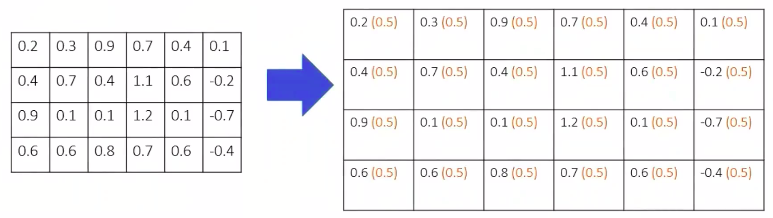</p>
<figcaption align="center">Figure 5: Original Neurons (left of arrow) adjusted by $p=0.5$ (right of arrow) during testing time</figcaption>
</figure>
</center>

The network is then trained and optimized. In the next iteration, another set of randomly chosen neurons are selected for these layers and masked, then trained and optimised. **This process is repeated until optimum point is reached**. The optimum point slightly changes than for the original network due to introduction of randomness.

For every iteration, a new neural network is generated. Looking at a particular neuron, we see that the **neuron doesnot rely on specific neurons in previous layer because any of the neurons in previous layer can go away at random.** Hence, weights will be spread out to each of the input neurons similar to L2 regularisation. We can use different values of keep.probability for different layers. **The disadvantage that arises while using dropout is number of hyperparameters to search for increases.**





We will set a probability and remove some units in hidden layers, making the model simpler than it was. We remove all the connections of the unit to be removed.

Let's illustrate implementation of dropout with layer $l = 3$:

$$
d_3 = np.random.rand(a_3.shape[0],\ a_3.shape[1]) < \text{keep\_prob}
$$

If 
$$
\text{keep\_prob} = 0.8,
$$
there is an 80% chance of keeping that hidden unit and a 20% chance of dropout.

Activation of 3rd layer:
$$
a_3 = np.multiply(a_3,\ d_3)
$$

The multiplication operation ends up zeroing out the corresponding elements of $a_3$.

Finally, we will take $a_3$ and scale it by dividing by keep\_prob (0.8 here):

Let's say, for the sake of argument, that we have 50 units or neurons in the 3rd hidden layer. So maybe $a_3$ is $50 \times m$ dimensional. If we have an 80% chance of keeping them and a 20% chance of removing them, this means on average, we end up with 10 units zeroed out. Now, if we look at the value of $z^4$, $z^4$ is going to be equal to $w^4 a^3 + b^4$. On expectation, this will be reduced by 20%, which means 20% of the elements of $a_3$ will be zeroed out. So, in order to not reduce the expected value of $z^4$, we need to divide $a_3$ by 0.8 because this will correct by roughly 20% that we need. So the expected value of $a_3$ won't be changed.

$$
a_3 = \frac{a_3}{\text{keep\_prob}}
$$

This equation for $a_3$ is called **inverted dropout**.  
If $\text{keep\_prob} = 1$, there is no dropout.

For different training examples, we zero out different hidden units. On different iterations, we'll zero out a different pattern of hidden units. Vector $d$ is used to determine which units to dropout both in forward propagation and in back propagation.

**No dropout is used at test time.** If we use dropout at test time, it will add noise to predictions.


##  Data Augmentation


### Introduction

One of the major challenges while developing models is **to gather and annotate data.** Often amount of data available is limited. Transforming available data and adding it to training set is one of the ways to get around this problem. We increase the training data but utilizing the same images we have and creating different versions of them. This approach of **increasing diversity of data available for training models by applying transformation to a existing training data is referred to as data augmentation.**

Having **small number of data leads to overfitting of neural networks and hence generalisation** cannot be achieved. We have already studied various techniques of preventing overfitting such as L1 regularisation, L2 regularisation and dropout. Apart from these methods overfitting can be reduced using data augmentation. Having **more data increases chance of a model to perform well on test set.**


###  Applcations of Data Augmentation



#### Images
Now let's consider we are developing a neural network that classifies handwritten digits, the dataset consists of only 1000 rows (1000 images with corresponding labels) and we can't get more data. We can **increase the size of data by rotating, blurring , flipping, shearing, shifting, scaling, distorting, cropping etc and adding them to the train dataset.** Following image shows some of these transformations.

<center>
<figure>


<p>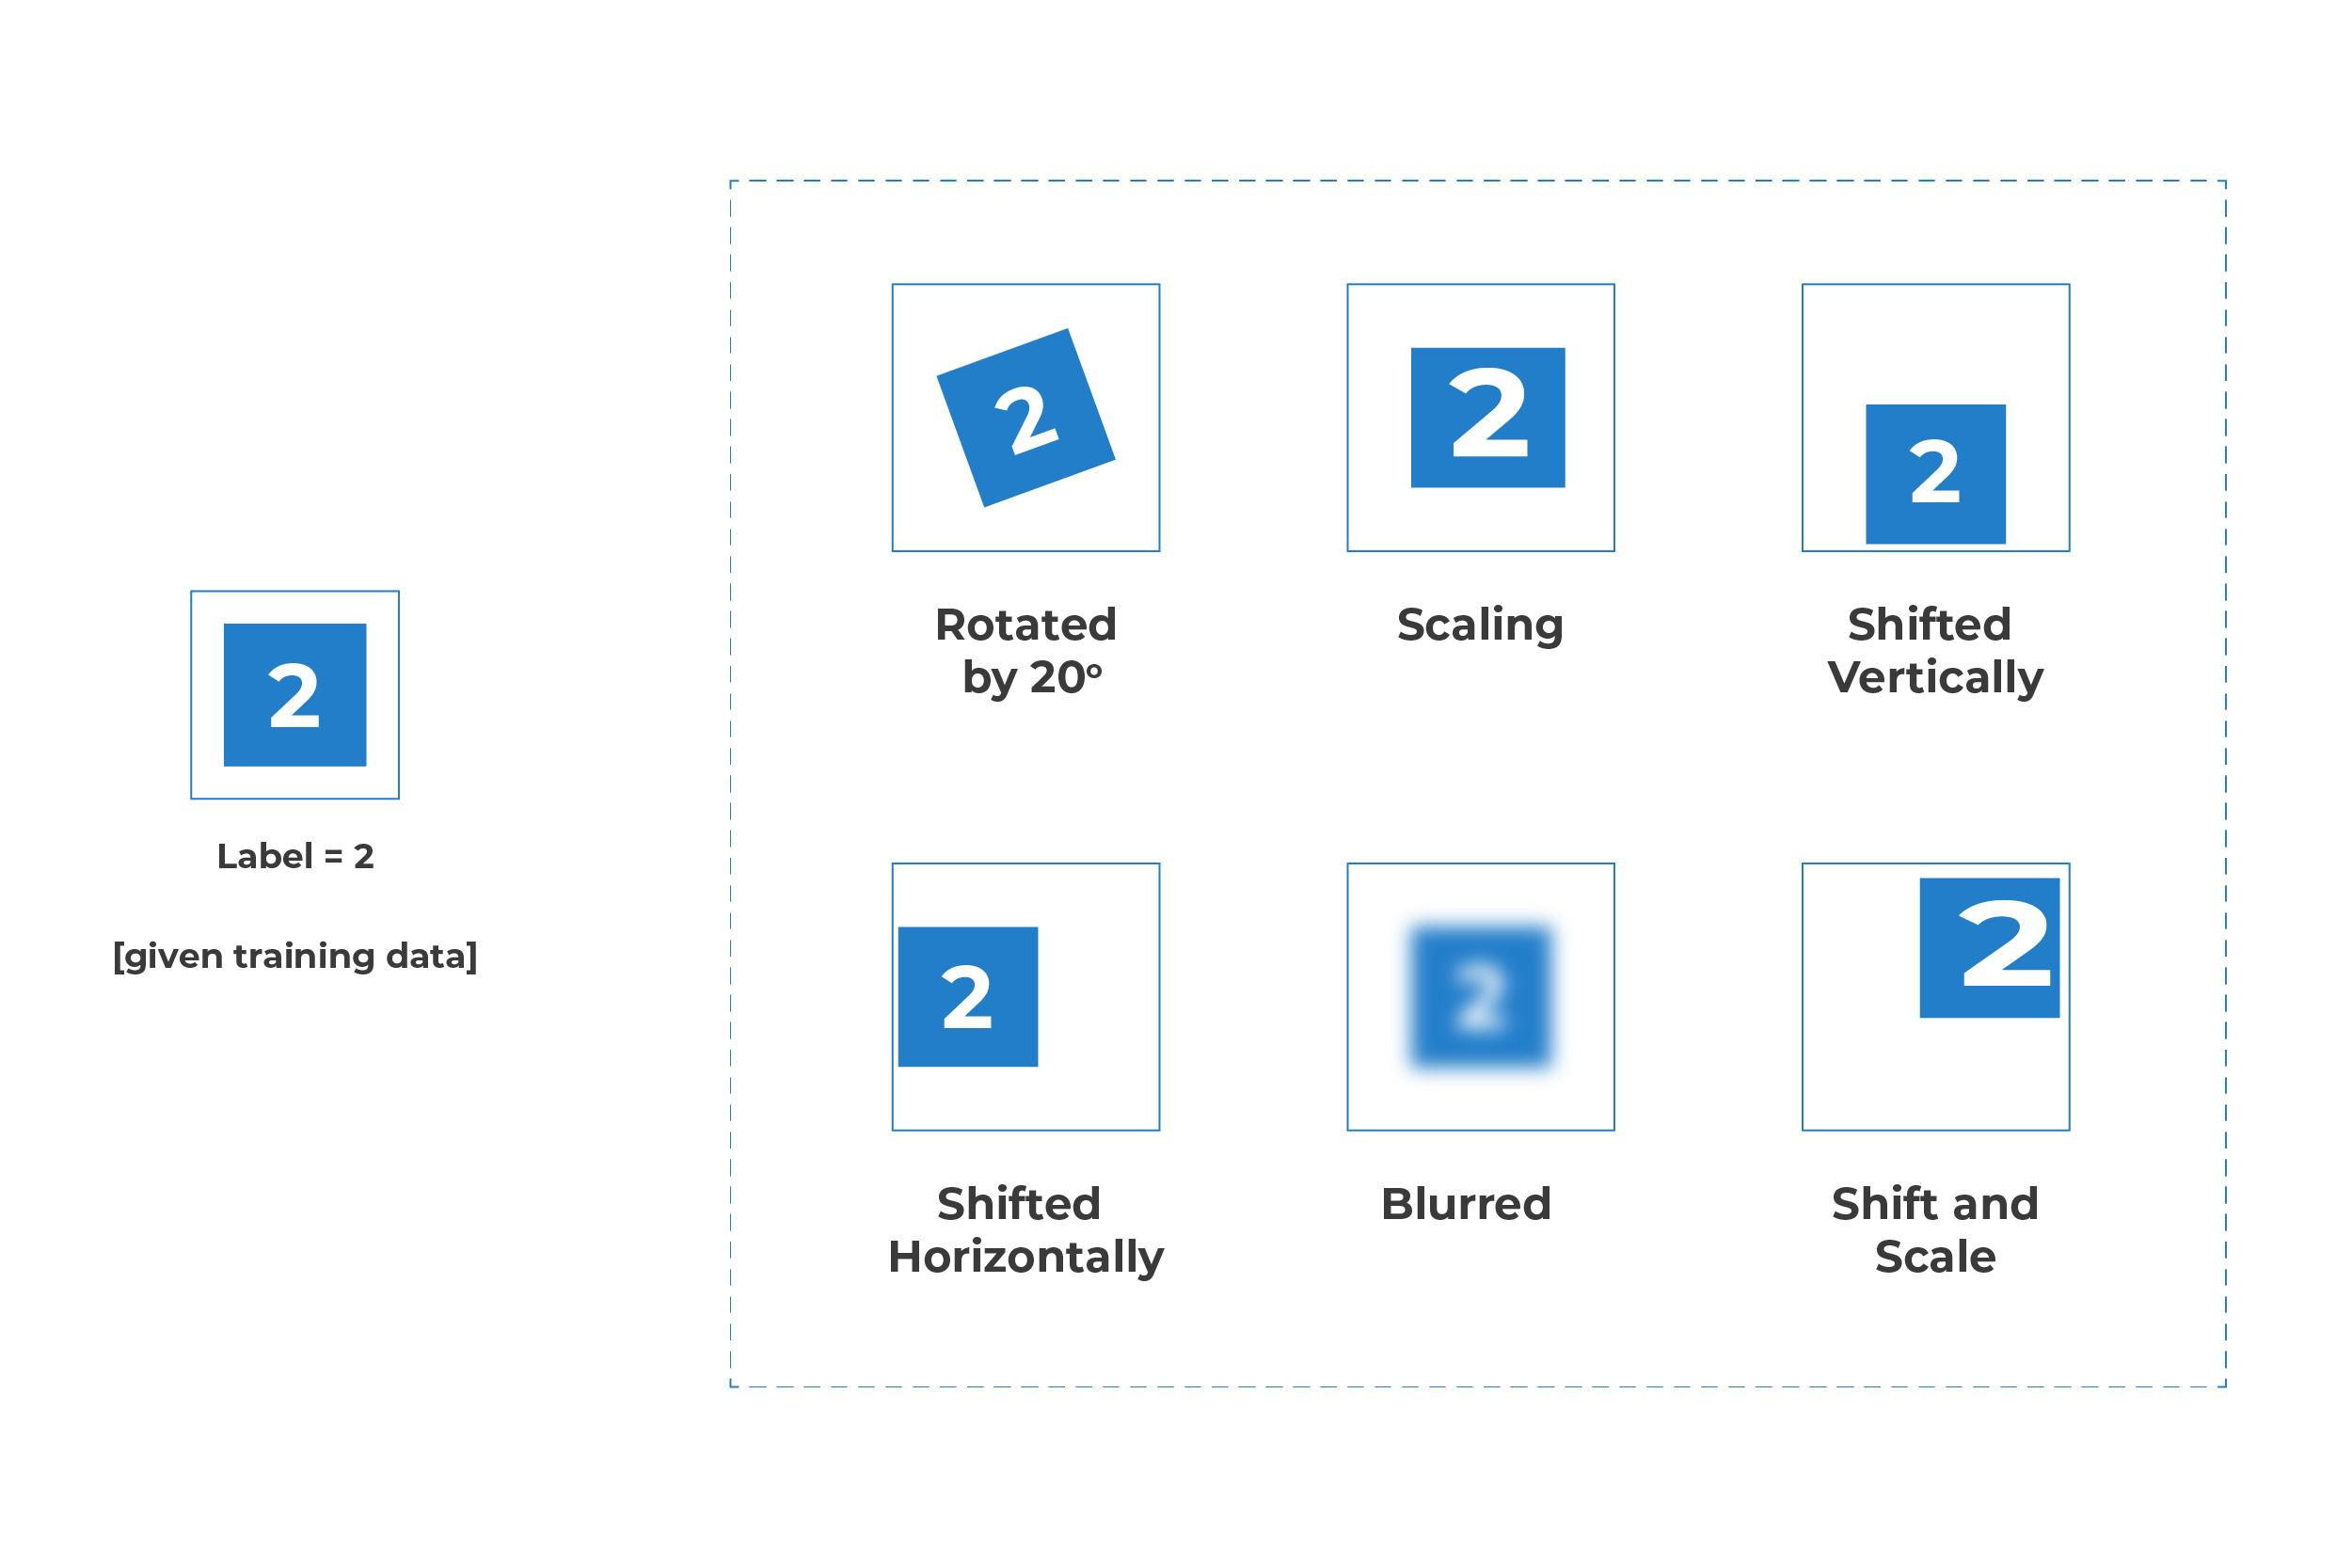</p>
<figcaption align="center">Figure 6: Data Augmentation techniques in Images </figcaption>
</figure>
</center>


We can use existing methods of present in frameworks such as **ImageDataGenerator in keras and transform** class present in torchvision of python. They consist of list of augments that help to pre-process training data.

Augmentation applied to dataset classification while classifying cats and dogs by rotating image by various angles, flipping and cropping is shown in figure below:

<center>
<figure>


<p>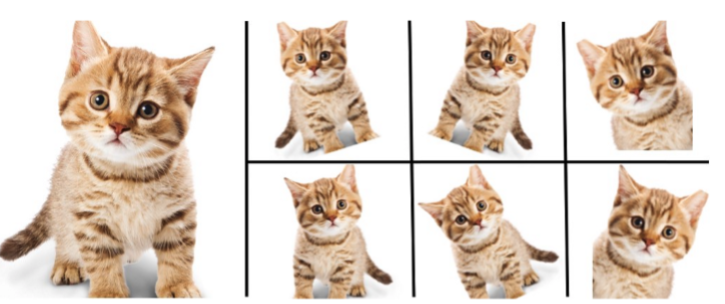</p>
<figcaption align="center">Figure 7: Data Augmentation Example </figcaption>
</figure>
</center>

Data augmentation using such transformations **make models shift invariant and translation invariant.** Besides these transformations, Generative adversarial networks, or GANs can be used to generate synthetic data to improve a classifier. GANs will be described later module.


#### Sound

Dataset augmentation techniques for sound are **noise injection, shifting, change of pitch and speed.**    
Noise injection can be done by adding some random value into data.   
The idea of shifting time is to shift audio left (fast forward) or right (back forward) with certain seconds (or milliseconds).   
Also pitch of original audio can be changed randomly.    
When changing speed of audio signal, time series is stretched by a fixed rate.

Results of applying these techniques to an audio wave is given below:

<center>
<figure>


<p>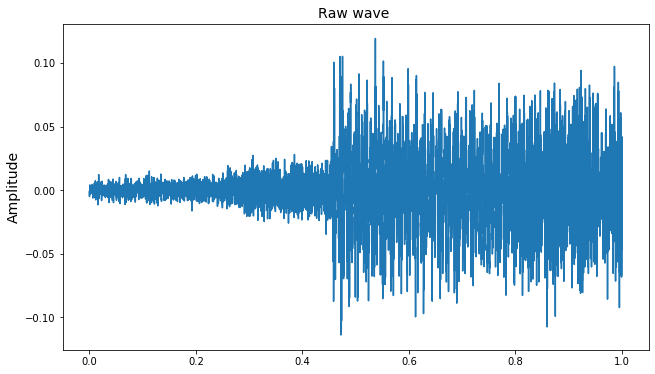</p>
<figcaption align="center">Figure 8: Raw </figcaption>
</figure>
</center>

<center>
<figure>


<p>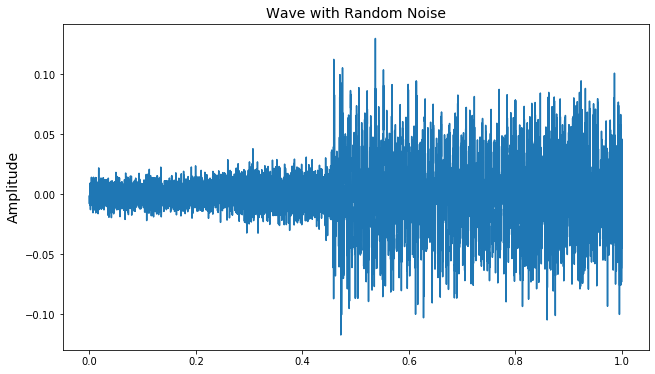</p>
<figcaption align="center">Figure 9: Noisy</figcaption>
</figure>
</center>

<center>
<figure>


<p>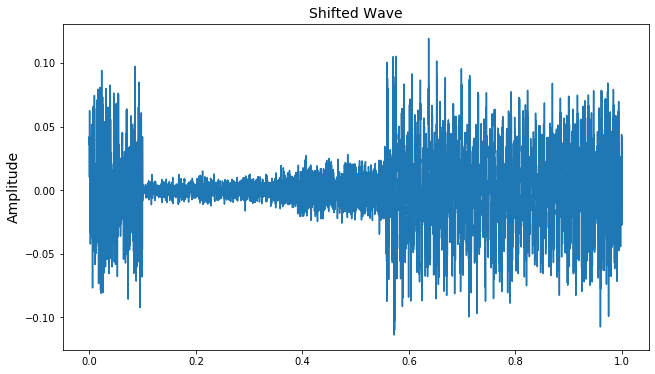</p>
<figcaption align="center">Figure 10: Shifted</figcaption>
</figure>
</center>

<center>
<figure>


<p>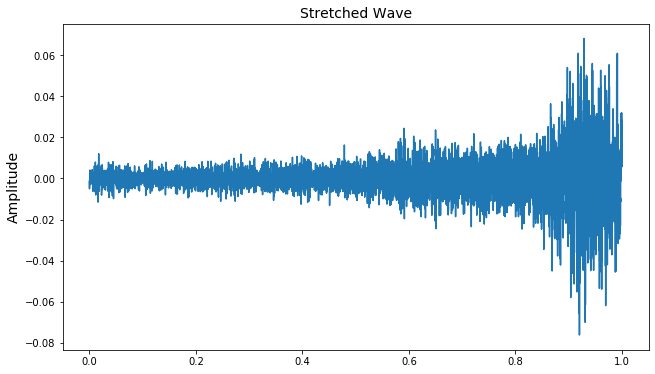</p>
<figcaption align="center">Figure 11: Stretched</figcaption>
</figure>
</center>






#### Natural Language Processing (NLP)

In contrast to augmenting images and audio, **augmenting texts is highly complex.** **Note every word can be simply replaced by another and not every word has synonym.** Changing one word of a sentence can change meaning of the entire sentence.    
For example, in the sentence "this car is not beautiful but interesting" when two words are swapped becomes "this car is not interesting but beautiful" completely changing meaning of the sentence.

Following are **Easy Data Augmentation (EDA) techniques in case of textual data:**

1. **Synonym Replacement (SR)**: We can randomly choose n words (which are not stop words) from a sentence and replace them with their synonyms.

2. **Random Insertion (RI)**: We can insert random synonym of words in a sentence n times.

3. **Random Swap (RS)**: We can randomly choose two words in a sentence and swap them. This process is repeated n times.

4. **Random Deletion (RD)**: We can randomly delete each word from a sentence with p probability.

The value of $n$ **differs for sentences to sentences depending upon length of each sentence.** $n$ can be large for longer sentences and should be small for shorter sentences. We can use following formula to determine value of $n$ for a sentence:

$$
n = \alpha L
$$

where, $\alpha$ is augmentation parameter and $L$ is length of the sentence. Higher is $\alpha$ more agressive is the EDA.

\

Beside above techniques, some other techniques for augmenting text-based data are given below:

* **Thesaurus:** Text augmentation can be done by replacing words or phrases with their synonyms. Large data can be generated in short time by using Thesaurus.
* **Embeddings:** Words can be replaced by another word similar to the original word. Such similar words can be found by using KNN and cosine similarity.
* **Back Translation:** Suppose we are developing english to japanese translator and donot have enough training data. We can translate target sentences to english sentences and augment such sentences to training data.
* **Paragraph Shuffling:** Sometimes shuffling paragraphs donot change the semantics of a text. For example we can swap two sections of a person's resume and there won't be much difference in the label (fit or not fit) of the resume.

Following is an example of data augmentation in NLP:

<center>
<figure>


<p>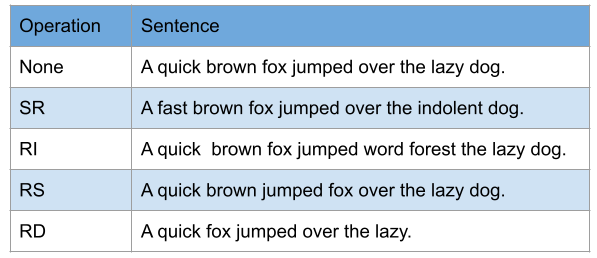</p>
<figcaption align="center">Figure 12: EDA techniques for NLP data augmentation</figcaption>
</figure>
</center>




## Key Takeaways
* Regularisation was introduced to make irregular curves more regular by introduing a penalty terms.

* High bias results in poor performance in both training and testing data where as high variance results in poor performance in testing data.

* Our goal is to reduce overfiting by reducing its generalization error without substantially increasing training error.

* Smaller weights in neural networks wont result in much significant change in behaviour of network whereas larger weights results in abrupt change in behaviour

* Regularization and gradient descent settle together at the point of intersection of contour map and region indicated by penalty terms.

* L1 addresses multi-collinearity problem by constraining the coefficent norm and reducing some coefficent values to zero where as L2 regularisation addresses it by constraining the coefficent norm and keeping all the variables.
* Dropout can also be thought of as bagging of many large neural networks.
* Dropout randomly removes some neurons with a probability of (1 - keep probability) and removes dependency of a particular neuron with some specific parent neurons which eventually removes overfitting
* The diversity of data can be increased by applying transformations of data to reduce the chance of model overfitting


## Resources
* [Bishop, Christopher M. Pattern recognition and machine learning. springer, 2006.](http://users.isr.ist.utl.pt/~wurmd/Livros/school/Bishop%20-%20Pattern%20Recognition%20And%20Machine%20Learning%20-%20Springer%20%202006.pdf)

* [Goodfellow, Ian, Yoshua Bengio, and Aaron Courville. Deep learning. MIT press, 2016.](https://www.deeplearningbook.org/)

* [Neal, B., Mittal, S., Baratin, A., Tantia, V., Scicluna, M., Lacoste-Julien, S., & Mitliagkas, I. (2018). A modern take on the bias-variance tradeoff in neural networks. arXiv preprint arXiv:1810.08591.](https://arxiv.org/pdf/1810.08591.pdf)

* [Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. (2014). Dropout: a simple way to prevent neural networks from overfitting. The journal of machine learning research, 15(1), 1929-1958.](https://www.cs.toronto.edu/~hinton/absps/JMLRdropout.pdf)

* [Read Regularization portion : cs231n notes](https://cs231n.github.io/neural-networks-2/#reg)
* [Kanburoğlu, A. B. (2018, May 27). Audio Data Augmentation.](https://medium.com/@alibugra/audio-data-augmentation-f26d716eee66)

* ["EDA: Easy Data Augmentation Techniques for Boosting Performance on Text Classification Tasks".](https://hackernoon.com/eda-easy-data-augmentation-techniques-for-boosting-performance-on-text-classification-tasks-bfb15f7a8a94)
